In [32]:
# ═══════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# Every library to be used in the project
# ═══════════════════════════════════════════════════════
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print(f"  GeoPandas {gpd.__version__}  |  Pandas {pd.__version__}")

Libraries loaded
  GeoPandas 1.1.3  |  Pandas 3.0.3


In [33]:
# ═══════════════════════════════════════════════════════
# CELL 2 — LOAD DATA provided by VIDA
# ═══════════════════════════════════════════════════════

# Load settlement data 
settlements = gpd.read_file('../data/raw/Benin_settlement_properties.geojson')

# Load transmission grid 
grid = gpd.read_file('../data/raw/Benin_existing_transmission_lines_2017.geojson')

print("=== DATA LOADED ===")
print(f"Settlements: {len(settlements):,} rows")
print(f"Grid lines: {len(grid):,} rows")
print(f"\nSettlement columns:")
for col in settlements.columns:
    print(f"  {col}: {settlements[col].dtype}")

=== DATA LOADED ===
Settlements: 17,205 rows
Grid lines: 36 rows

Settlement columns:
  lat: float64
  lon: float64
  demand: float64
  mean_rwi: float64
  hull_area: float64
  identifier: int32
  population: int32
  buffer_area: float64
  description: object
  admin_cgaz_0: str
  admin_cgaz_1: str
  admin_cgaz_2: str
  overlap_area: float64
  village_name: str
  bf_total_area: float64
  energy_demand: float64
  num_buildings: int32
  has_nightlight: bool
  large_buildings: int32
  num_connections: int32
  small_buildings: int32
  building_density: float64
  main_road_access: bool
  medium_buildings: int32
  nearest_hub_name: str
  pv_size_category: str
  Buildings_per_km2: float64
  demand_connection: float64
  dist_main_road_km: float64
  dist_lake_river_km: float64
  overlap_percentage: float64
  dist_nearest_hub_km: float64
  dist_to_substations: float64
  has_health_facility: bool
  dist_to_regional_hubs: float64
  num_health_facilities: int32
  very_small_structures: int32
  clos

In [34]:
# ═══════════════════════════════════════════════════════
# CELL 3 — EXPLORE SETTLEMENTS
# Understand the range and distribution of key variables
# ═══════════════════════════════════════════════════════

print("=== KEY STATISTICS ===")

# Population
print(f"\nPopulation per settlement:")
print(f"  Smallest: {settlements['population'].min()} people")
print(f"  Largest: {settlements['population'].max():,} people")
print(f"  Average: {settlements['population'].mean():.0f} people")
print(f"  Median: {settlements['population'].median():.0f} people")
print(f"  Total: {settlements['population'].sum():,} people")

# Distance to grid
print(f"\nDistance to existing transmission line:")
print(f"  Closest: {settlements['distance_to_existing_transmission_lines'].min():.1f} km")
print(f"  Furthest: {settlements['distance_to_existing_transmission_lines'].max():.1f} km")
print(f"  Average: {settlements['distance_to_existing_transmission_lines'].mean():.1f} km")
print(f"  Median: {settlements['distance_to_existing_transmission_lines'].median():.1f} km")

# Electrification status
electrified = settlements['has_nightlight'].sum()
unelectrified = (~settlements['has_nightlight']).sum()
print(f"\nElectrification status:")
print(f"  Already electrified (has nightlight): {electrified:,} ({electrified/len(settlements)*100:.1f}%)")
print(f"  Unelectrified (our target): {unelectrified:,} ({unelectrified/len(settlements)*100:.1f}%)")

# Social services
print(f"\nSocial services:")
print(f"  Has health facility: {settlements['has_health_facility'].sum():,}")
print(f"  Has education facility: {settlements['has_education_facility'].sum():,}")

# Departments
print(f"\nSettlements by department:")
print(settlements['admin_cgaz_1'].value_counts().to_string())

=== KEY STATISTICS ===

Population per settlement:
  Smallest: 10 people
  Largest: 2,348,441 people
  Average: 820 people
  Median: 98 people
  Total: 14,111,192 people

Distance to existing transmission line:
  Closest: 0.0 km
  Furthest: 244.8 km
  Average: 42.1 km
  Median: 22.6 km

Electrification status:
  Already electrified (has nightlight): 910 (5.3%)
  Unelectrified (our target): 16,295 (94.7%)

Social services:
  Has health facility: 274
  Has education facility: 1,391

Settlements by department:
admin_cgaz_1
Alibori            3087
Borgou             2728
Atakora            2515
Donga              1495
Atlantique         1415
Zou                1251
Collines           1181
Plateau            1121
Kouffo             1064
Mono                968
Ouémé               350
Kebbi                 8
Maritime Region       4
Ogun                  3
Kwara                 2
Dossa                 2


In [35]:
# ═══════════════════════════════════════════════════════
# CELL 4 — INDEPENDENT UNELECTRIFIED BENIN-ONLY FILTER FOR GEE
# ═══════════════════════════════════════════════════════
settlements['admin_cgaz_1'] = settlements['admin_cgaz_1'].str.upper().str.strip()

BENIN_DEPTS_CAPS = [
    'ALIBORI', 'ATAKORA', 'ATLANTIQUE', 'BORGOU', 
    'COLLINES', 'DONGA', 'KOUFFO', 'LITTORAL', 
    'MONO', 'OUÉMÉ', 'PLATEAU', 'ZOU'
]

# GEE Export dataframe
# Filter: Must be in Benin list AND must be unelectrified
gee_export_final = settlements[
    (settlements['admin_cgaz_1'].isin(BENIN_DEPTS_CAPS)) & 
    (settlements['has_nightlight'] == False)
].copy()

# MISSING DEPARTMENT DIAGNOSTIC
print("=== GEE EXPORT VALIDATION ===")
found_depts = gee_export_final['admin_cgaz_1'].unique()
missing_depts = [d for d in BENIN_DEPTS_CAPS if d not in found_depts]

if not missing_depts:
    print("SUCCESS: All 12 departments are accounted for.")
else:
    print(f"NOTE: {len(missing_depts)} departments have 0 unelectrified settlements: {missing_depts}")
    

# FINAL COUNT CHECK
print(f"\nTotal Unelectrified Settlements: {len(gee_export_final):,}")
print(f"Total Population in Export: {gee_export_final['population'].sum():,}")

# Save

gee_export_final[['village_name', 'lat', 'lon', 'population']].to_csv(
    '../data/processed/Benin_Unelectrified_Final.csv', 
        index=False
    )
print("\n CSV SAVED: 'Benin_Unelectrified_Final.csv'")


=== GEE EXPORT VALIDATION ===
NOTE: 1 departments have 0 unelectrified settlements: ['LITTORAL']

Total Unelectrified Settlements: 16,273
Total Population in Export: 3,948,886

 CSV SAVED: 'Benin_Unelectrified_Final.csv'


In [36]:
# ═══════════════════════════════════════════════════════
# CELL 5 — Load All Data
# ═══════════════════════════════════════════════════════

# ── VIDA DATA ─────────────────────────────────────────────
settlements = gpd.read_file('../data/raw/Benin_settlement_properties.geojson')
grid        = gpd.read_file('../data/raw/Benin_existing_transmission_lines_2017.geojson')

# GOOGLE EARTH ENGINE DATA 

gee = pd.read_csv('../data/raw/Benin_GEE_Master.csv')

print(f"Settlements:  {len(settlements):,}")
print(f"Grid lines:   {len(grid)}")
print(f"GEE records:  {len(gee):,}")
print(f"\nGEE columns: {list(gee.columns)}")

Settlements:  17,205
Grid lines:   36
GEE records:  16,233

GEE columns: ['identifier', 'village_name', 'lat', 'lon', 'viirs_radiance', 'solar_radiation_j', 'landuse_code', 'terrain_slope_deg', 'ndvi', 'worldpop_density', 'rainfall_mm']


In [37]:
# ═══════════════════════════════════════════════════════
# CELL 6 — PROCESS GEE SATELLITE DATA
# ═══════════════════════════════════════════════════════

ESA_CODES = {
    10: 'Forest',        20: 'Shrubland',       30: 'Grassland',
    40: 'Cropland',      50: 'Built-up',         60: 'Bare vegetation',
    80: 'Water body',    90: 'Wetland',           95: 'Mangrove'
}

# Decode land use
gee['landuse_label'] = gee['landuse_code'].map(ESA_CODES).fillna('Unknown')

# Convert solar: J/m²/month → kWh/m²/day
# Divide by 3,600,000 (J→kWh) then by 30 (month→day)
gee['solar_ghi_kwh'] = (gee['solar_radiation_j'] / 3_600_000 / 30).round(3)

# Classify VIIRS into electrification status
def classify_viirs(rad):
    if rad > 1.0:   return 'Electrified'
    elif rad > 0.5: return 'Partial electricity'
    else:           return 'No electricity'

gee['viirs_status'] = gee['viirs_radiance'].apply(classify_viirs)

# Round lat/lon for joining (4 decimal places = ~11m precision)
gee['lat_r'] = gee['lat'].round(4)
gee['lon_r'] = gee['lon'].round(4)

print("GEE data processed")
print(f"\nSolar GHI: {gee['solar_ghi_kwh'].mean():.2f} kWh/m²/day mean "
      f"(Benin expected 4.5–6.5 ✓)")
print(f"\nVIIRS electrification status:")
print(gee['viirs_status'].value_counts().to_string())
print(f"\nESA land use:")
print(gee['landuse_label'].value_counts().to_string())
print(f"\nNDVI mean: {gee['ndvi'].mean():.3f} (0=bare, 0.8=dense vegetation)")
print(f"Slope mean: {gee['terrain_slope_deg'].mean():.2f}° "
      f"(steep >10°: {(gee['terrain_slope_deg']>10).sum():,} settlements)")
print(f"Rainfall mean: {gee['rainfall_mm'].mean():.0f} mm/year")

GEE data processed

Solar GHI: 5.49 kWh/m²/day mean (Benin expected 4.5–6.5 ✓)

VIIRS electrification status:
viirs_status
No electricity         15303
Partial electricity      852
Electrified               78

ESA land use:
landuse_label
Cropland           6176
Forest             4075
Shrubland          3825
Grassland          1651
Built-up            412
Wetland              50
Water body           20
Mangrove             17
Bare vegetation       7

NDVI mean: 0.402 (0=bare, 0.8=dense vegetation)
Slope mean: 0.92° (steep >10°: 7 settlements)
Rainfall mean: 1184 mm/year


In [38]:
# ═══════════════════════════════════════════════════════
# CELL 7 — JOINING GEE DATA TO SETTLEMENTS
# ═══════════════════════════════════════════════════════

# Round settlements lat/lon for join
settlements['lat_r'] = settlements['lat'].round(4)
settlements['lon_r'] = settlements['lon'].round(4)

# Select GEE columns to bring across
gee_cols = ['lat_r', 'lon_r', 'viirs_radiance', 'solar_ghi_kwh',
            'landuse_code', 'landuse_label', 'terrain_slope_deg',
            'ndvi', 'worldpop_density', 'rainfall_mm', 'viirs_status']

# Left join — keep all 17,205 settlements
enriched = settlements.merge(gee[gee_cols], on=['lat_r', 'lon_r'], how='left')

# Fill missing GEE values with our own extraction averages
BENIN_SOLAR    = gee['solar_ghi_kwh'].mean()     # 5.49 kWh/m²/day
BENIN_VIIRS    = gee['viirs_radiance'].median()  
BENIN_NDVI     = gee['ndvi'].mean()
BENIN_RAINFALL = gee['rainfall_mm'].mean()

enriched['solar_ghi_kwh']    = enriched['solar_ghi_kwh'].fillna(BENIN_SOLAR)
enriched['viirs_radiance']   = enriched['viirs_radiance'].fillna(BENIN_VIIRS)
enriched['ndvi']             = enriched['ndvi'].fillna(BENIN_NDVI)
enriched['rainfall_mm']      = enriched['rainfall_mm'].fillna(BENIN_RAINFALL)
enriched['landuse_label']    = enriched['landuse_label'].fillna('Unknown')
enriched['terrain_slope_deg']= enriched['terrain_slope_deg'].fillna(0.92)
enriched['worldpop_density'] = enriched['worldpop_density'].fillna(1.44)
enriched['viirs_status']     = enriched['viirs_status'].fillna('Electrified')
# Missing = large urban settlements already electrified

# Fill missing RWI with department median
enriched['mean_rwi'] = enriched.groupby('admin_cgaz_1')['mean_rwi']    .transform(lambda x: x.fillna(x.median()))

matched = enriched['viirs_radiance'].notna().sum()
print(f"Join results:")
print(f"  Total settlements:      {len(enriched):,}")
print(f"  Matched with GEE:       {len(gee):,} ({len(gee)/len(enriched)*100:.1f}%)")
print(f"  Filled with averages:   {len(enriched)-len(gee):,}")

Join results:
  Total settlements:      17,205
  Matched with GEE:       16,233 (94.4%)
  Filled with averages:   972


In [39]:
# ═══════════════════════════════════════════════════════
# CELL 8 — ELECTRIFICATION BASELINE IN BENIN ONLY
# ═══════════════════════════════════════════════════════

# ── FILTER TO BENIN ───────────────────────────────────
BENIN_DEPARTMENTS = [
    'Alibori','Borgou','Atakora','Donga','Atlantique',
    'Zou','Collines','Plateau','Kouffo','Mono','Ouémé','Littoral'
]

benin = enriched[enriched['admin_cgaz_1'].isin(BENIN_DEPARTMENTS)].copy()

# ELECTRIFICATION FILTER 


unelectrified = benin[benin['has_nightlight'] == False].copy()
electrified   = benin[benin['has_nightlight'] == True].copy()

HOUSEHOLD_SIZE = 5.2
unelectrified['num_households'] = (
    unelectrified['population'] / HOUSEHOLD_SIZE
).round(0).astype(int)

total_pop  = benin['population'].sum()
unelec_pop = unelectrified['population'].sum()

print("=" * 52)
print("BENIN ELECTRIFICATION BASELINE")
print("=" * 52)
print(f"  Total Benin population:       {total_pop:>10,}")
print(f"  With electricity:             {electrified['population'].sum():>10,} "
      f"({electrified['population'].sum()/total_pop*100:.1f}%)")
print(f"  Zero electricity (target):    {unelec_pop:>10,} "
      f"({unelec_pop/total_pop*100:.1f}%)")
print(f"  Planning target settlements:  {len(unelectrified):>10,}")
print(f"  Planning target households:   {unelectrified['num_households'].sum():>10,}")
print(f"\nBy department:")
print(unelectrified['admin_cgaz_1'].value_counts().to_string())

BENIN ELECTRIFICATION BASELINE
  Total Benin population:       14,063,161
  With electricity:             10,114,275 (71.9%)
  Zero electricity (target):     3,948,886 (28.1%)
  Planning target settlements:      16,273
  Planning target households:      758,686

By department:
admin_cgaz_1
Alibori       3018
Borgou        2591
Atakora       2432
Donga         1415
Atlantique    1302
Zou           1182
Collines      1091
Plateau       1076
Kouffo         975
Mono           869
Ouémé          322


In [40]:
# ═══════════════════════════════════════════════════════
# CELL 9 — RELATIVE WEALTH INDEX(RWI) ANALYSIS
# ═══════════════════════════════════════════════════════
def assign_wealth_tier(rwi):
    """
    W1 Very Poor  (< -0.6):  subsistence farmers — need full subsidy
    W2 Poor       (-0.6 to -0.3): small farmers — subsidised PAYGO
    W3 Average    (-0.3 to  0.0): mixed livelihoods — standard PAYGO
    W4 Above avg  ( 0.0 to  0.5): regular income — mini-grid tariff
    W5 Wealthy    (>  0.5):  business/formal sector — commercial tariff
    """
    if rwi >= 0.5:    return 'W5'
    elif rwi >= 0.0:  return 'W4'
    elif rwi >= -0.3: return 'W3'
    elif rwi >= -0.6: return 'W2'
    else:             return 'W1'

FINANCING_MODEL = {
    'W1': 'Subsidy required (World Bank / MCC grant)',
    'W2': 'Subsidised PAYGO (DFI-backed — ENGIE EIB model)',
    'W3': 'Standard PAYGO ($0.19/day — ENGIE Benin)',
    'W4': 'Mini-grid tariff (private operator + ABERME licence)',
    'W5': 'Commercial tariff (full market rate)'
}

unelectrified['wealth_tier']     = unelectrified['mean_rwi'].apply(assign_wealth_tier)
unelectrified['financing_model'] = unelectrified['wealth_tier'].map(FINANCING_MODEL)

print("=== WEALTH TIER DISTRIBUTION ===")
print(f"{'Tier':<6} {'Settlements':>11} {'%':>6} {'Population':>12} {'Avg km to grid':>15}")
print("─" * 54)
for tier in ['W1','W2','W3','W4','W5']:
    sub  = unelectrified[unelectrified['wealth_tier']==tier]
    pop  = sub['population'].sum()
    dist = sub['distance_to_existing_transmission_lines'].mean()
    pct  = len(sub)/len(unelectrified)*100
    print(f"{tier:<6} {len(sub):>11,} {pct:>5.1f}% {pop:>12,} {dist:>14.1f}km")

w1  = unelectrified[unelectrified['wealth_tier']=='W1']
w45 = unelectrified[unelectrified['wealth_tier'].isin(['W4','W5'])]
print(f"\nENERGY POVERTY TRAP:")
print(f"  Poorest (W1) avg distance to grid:   {w1['distance_to_existing_transmission_lines'].mean():.1f}km")
print(f"  Wealthiest (W4/W5) avg distance:     {w45['distance_to_existing_transmission_lines'].mean():.1f}km")
print(f"  The poorest live furthest from electricity.")
print(f"  Grid extension is structurally unavailable to those who need it most.")

=== WEALTH TIER DISTRIBUTION ===
Tier   Settlements      %   Population  Avg km to grid
──────────────────────────────────────────────────────
W1           2,824  17.4%      467,014           45.8km
W2           8,128  49.9%    1,801,364           46.7km
W3           3,948  24.3%    1,194,034           40.0km
W4           1,240   7.6%      444,405           24.9km
W5             133   0.8%       42,069           15.8km

ENERGY POVERTY TRAP:
  Poorest (W1) avg distance to grid:   45.8km
  Wealthiest (W4/W5) avg distance:     24.0km
  The poorest live furthest from electricity.
  Grid extension is structurally unavailable to those who need it most.


In [41]:
# ═══════════════════════════════════════════════════════
# CELL 10 — MTF DEMAND TIER ASSIGNMENT
# ═══════════════════════════════════════════════════════

TIER_DEMAND_KWH = {1: 22, 2: 73, 3: 365, 4: 1250}

def assign_mtf_tier(row):
    """
    Multi-signal tier assignment using:
    - Population (demand volume)
    - Large buildings (anchor loads — clinics, schools, mills)
    - ESA land use (cropland = productive demand)
    - NDVI (confirms active agriculture on cropland)
    - RWI wealth tier (consumption expectations)
    """
    pop         = row['population']
    large_bldgs = row.get('large_buildings', 0) or 0
    has_health  = row['has_health_facility']
    has_edu     = row['has_education_facility']
    landuse     = row.get('landuse_label', '')
    wealth      = row['wealth_tier']
    ndvi        = row.get('ndvi', 0.4) or 0.4

    # Active cropland = NDVI > 0.3 on cropland = confirmed productive use
    active_cropland = (landuse == 'Cropland') and (ndvi > 0.3)

    # Tier 4 — peri-urban commercial scale
    if (pop > 3000 or
       (pop > 1500 and landuse == 'Built-up') or
       (pop > 2000 and wealth in ['W4','W5'])):
        return 4

    # Tier 3 — service centre or anchor loads or productive use
    elif (pop >= 300 or has_health or has_edu or
          large_bldgs > 0 or active_cropland or
          wealth in ['W4','W5']):
        return 3

    # Tier 2 — small village
    elif pop >= 100:
        return 2

    # Tier 1 — remote hamlet
    else:
        return 1

unelectrified['mtf_tier'] = unelectrified.apply(assign_mtf_tier, axis=1)

print("=== MTF TIER ASSIGNMENT ===")
tier_info = {
    1: "22 kWh/yr  — 2 bulbs + phone",
    2: "73 kWh/yr  — bulbs + fan + radio",
    3: "365 kWh/yr — TV + fridge + productive",
    4: "1,250 kWh/yr — full + commercial"
}
for t in [1,2,3,4]:
    sub = unelectrified[unelectrified['mtf_tier']==t]
    pct = len(sub)/len(unelectrified)*100
    print(f"  Tier {t} ({tier_info[t]})")
    print(f"    {len(sub):,} settlements ({pct:.1f}%)  |  {sub['population'].sum():,} people")

=== MTF TIER ASSIGNMENT ===
  Tier 1 (22 kWh/yr  — 2 bulbs + phone)
    5,035 settlements (30.9%)  |  293,891 people
  Tier 2 (73 kWh/yr  — bulbs + fan + radio)
    2,466 settlements (15.2%)  |  398,563 people
  Tier 3 (365 kWh/yr — TV + fridge + productive)
    8,567 settlements (52.6%)  |  2,530,424 people
  Tier 4 (1,250 kWh/yr — full + commercial)
    205 settlements (1.3%)  |  726,008 people


In [42]:
# ═══════════════════════════════════════════════════════
# CELL 11 — DEMAND ESTIMATION
# ═══════════════════════════════════════════════════════

PLANNING_HORIZON     = 15
DEMAND_GROWTH_RATE   = 0.03
ELECTRIFICATION_RATE = 0.70
HEALTH_KWH_YR        = 500
EDUCATION_KWH_YR     = 300

TIER_DEMAND_KWH = {1: 22, 2: 73, 3: 365, 4: 1250}

RWI_DEMAND_FACTOR = {
    'W1': 0.80, 'W2': 0.90, 'W3': 1.00,
    'W4': 1.10, 'W5': 1.20
}

PRODUCTIVE_UPLIFT = {
    'Cropland': 0.25, 'Built-up': 0.30, 'Grassland': 0.10,
    'Shrubland': 0.05, 'Forest': 0.05,
    'Bare vegetation': 0.0, 'Water body': 0.0,
    'Wetland': 0.0, 'Unknown': 0.05
}

def rainfall_adj(mm):
    if mm < 900:    return 1.15
    elif mm < 1200: return 1.00
    else:           return 0.95

# GUARD: check required columns exist 
required = ['mtf_tier', 'wealth_tier', 'num_households',
            'num_health_facilities', 'num_education_facilities',
            'landuse_label', 'rainfall_mm']
missing_cols = [c for c in required if c not in unelectrified.columns]
if missing_cols:
    print(f"ERROR — missing columns: {missing_cols}")
    print("Run Cells 5, 6, 7 first then re-run this cell")
else:
    # Base demand
    unelectrified['kwh_per_hh_base'] = (
        unelectrified['mtf_tier'].map(TIER_DEMAND_KWH)
    )
    unelectrified['rwi_factor'] = (
        unelectrified['wealth_tier'].map(RWI_DEMAND_FACTOR)
    )
    unelectrified['rainfall_factor'] = (
        unelectrified['rainfall_mm'].apply(rainfall_adj)
    )
    unelectrified['kwh_per_hh'] = (
        unelectrified['kwh_per_hh_base'] *
        unelectrified['rwi_factor'] *
        unelectrified['rainfall_factor']
    )

    # Residential
    unelectrified['residential_demand'] = (
        unelectrified['num_households'] *
        unelectrified['kwh_per_hh'] *
        ELECTRIFICATION_RATE
    )

    # Institutional (anchor loads)
    unelectrified['institutional_demand'] = (
        unelectrified['num_health_facilities'] * HEALTH_KWH_YR +
        unelectrified['num_education_facilities'] * EDUCATION_KWH_YR
    )

    # Productive use from land use
    unelectrified['productive_factor'] = (
        unelectrified['landuse_label']
        .map(PRODUCTIVE_UPLIFT)
        .fillna(0.05)
    )
    unelectrified['productive_demand'] = (
        unelectrified['residential_demand'] *
        unelectrified['productive_factor']
    )

    # Total Year 1 demand
    unelectrified['total_demand_yr1'] = (
        unelectrified['residential_demand'] +
        unelectrified['institutional_demand'] +
        unelectrified['productive_demand']
    )

    # Project 15 years
    for year in range(1, PLANNING_HORIZON + 1):
        unelectrified[f'demand_yr{year}'] = (
            unelectrified['total_demand_yr1'] *
            (1 + DEMAND_GROWTH_RATE) ** (year - 1)
        )

    # Validate
    print("=" * 45)
    print("DEMAND ESTIMATION COMPLETE")
    print("=" * 45)
    print(f"  Settlements:    {len(unelectrified):,}")
    print(f"  total_demand_yr1 created: ✓")
    print(f"\n  Demand breakdown Year 1:")
    print(f"    Residential:   {unelectrified['residential_demand'].sum():>12,.0f} kWh")
    print(f"    Institutional: {unelectrified['institutional_demand'].sum():>12,.0f} kWh")
    print(f"    Productive:    {unelectrified['productive_demand'].sum():>12,.0f} kWh")
    print(f"    {'─'*30}")
    print(f"    TOTAL Year 1:  {unelectrified['total_demand_yr1'].sum():>12,.0f} kWh")
    print(f"    TOTAL Year 15: {unelectrified['demand_yr15'].sum():>12,.0f} kWh")
    print(f"\n  Null check on total_demand_yr1: "
          f"{unelectrified['total_demand_yr1'].isna().sum()} nulls")

DEMAND ESTIMATION COMPLETE
  Settlements:    16,273
  total_demand_yr1 created: ✓

  Demand breakdown Year 1:
    Residential:    235,963,689 kWh
    Institutional:      423,100 kWh
    Productive:      38,898,080 kWh
    ──────────────────────────────
    TOTAL Year 1:   275,284,869 kWh
    TOTAL Year 15:  416,393,064 kWh

  Null check on total_demand_yr1: 0 nulls


In [43]:
# ═══════════════════════════════════════════════════════
# CELL 12 — TECHNOLOGY COSTS AND LCOE FUNCTIONS
# ═══════════════════════════════════════════════════════

DISCOUNT_RATE = 0.10  # World Bank standard for SSA

TECH_COSTS = {
    'Grid_Extension': {
        'capex_connection': 500,    # USD per household connection
        'capex_per_km':    15000,   # USD per km MV line
        'opex_rate':        0.02,   # 2% of CAPEX per year
        'lifetime':         30,
    },
    'Mini_Grid': {
        'capex_connection': 900,    # USD per connection (revised from 1200)
        # Source: ENGIE West Africa small community systems
        'capex_fixed':     15000,   # USD fixed infrastructure (revised from 50000)
        # Small solar MG serving 50-200 HH: $15,000-25,000
        # ENGIE Dohoue (1500 people) was $50k+ — larger system
        'opex_rate':        0.05,
        'lifetime':         20,
        'min_pop':          250,
    },
    'SHS': {
        'capex_tier12': 200,    # Tier 1-2 SHS — ENGIE PAYGO product
        'capex_tier34': 400,    # Tier 3+ larger system
        'opex_rate':    0.03,
        'lifetime':     10,
    }
}

def npv_factor(rate, years):
    """Discount factor — time value of money"""
    return sum([1/(1+rate)**t for t in range(1, years+1)])

def solar_capex_adj(ghi):
    """
    Adjust solar CAPEX using per-settlement GHI from GEE
    Better solar = more energy per panel = lower unit cost
    Reference: Benin average 5.49 kWh/m²/day
    Range: ±15%
    """
    return max(0.85, min(1.15, 1 - 0.05*(ghi - 5.49)/5.49))

def slope_capex_adj(slope_deg):
    """
    Increase CAPEX for steep terrain from GEE SRTM data
    Affects equipment transport and pole installation cost
    """
    if slope_deg <= 5:    return 1.00
    elif slope_deg <= 10: return 1.10
    else:                 return 1.20

def get_connections(row):
    """
    Derive number of connectable households from population
    More reliable than num_connections column which is often
    null or defaults to 1 in the data
    """
    hh = max(int(row['population'] / 5.2 * 0.70), 5)
    return hh

def lcoe_grid(row, costs, dr):
    """Grid extension — cost driven by distance to MV line"""
    dist  = row['distance_to_existing_transmission_lines']
    conns = get_connections(row)
    slope = row.get('terrain_slope_deg', 0) or 0
    lt    = costs['Grid_Extension']['lifetime']
    capex = (dist * costs['Grid_Extension']['capex_per_km'] +
             conns * costs['Grid_Extension']['capex_connection']) * slope_capex_adj(slope)
    opex  = capex * costs['Grid_Extension']['opex_rate']
    nrg   = max(row['total_demand_yr1'], 1)
    return round((capex + opex*npv_factor(dr,lt)) / (nrg*npv_factor(dr,lt)), 4), round(capex,0)

def lcoe_mg(row, costs, dr):
    """Mini-grid — fixed + per-connection; solar and slope adjusted"""
    conns = get_connections(row)
    slope = row.get('terrain_slope_deg', 0) or 0
    ghi   = row.get('solar_ghi_kwh', 5.49) or 5.49
    lt    = costs['Mini_Grid']['lifetime']
    capex = (costs['Mini_Grid']['capex_fixed'] +
             conns * costs['Mini_Grid']['capex_connection']) * \
             solar_capex_adj(ghi) * slope_capex_adj(slope)
    opex  = capex * costs['Mini_Grid']['opex_rate']
    nrg   = max(row['total_demand_yr1'], 1)
    return round((capex + opex*npv_factor(dr,lt)) / (nrg*npv_factor(dr,lt)), 4), round(capex,0)

def lcoe_shs(row, costs, dr):
    """SHS — per-household; larger for Tier 3+; solar adjusted"""
    conns = get_connections(row)
    ghi   = row.get('solar_ghi_kwh', 5.49) or 5.49
    lt    = costs['SHS']['lifetime']
    cap   = costs['SHS']['capex_tier34'] if row['mtf_tier'] >= 3 \
            else costs['SHS']['capex_tier12']
    capex = conns * cap * solar_capex_adj(ghi)
    opex  = capex * costs['SHS']['opex_rate']
    nrg   = max(row['total_demand_yr1'], 1)
    return round((capex + opex*npv_factor(dr,lt)) / (nrg*npv_factor(dr,lt)), 4), round(capex,0)

print("LCOE functions ready")
print(f"\nExpected LCOE ranges for Benin:")
print(f"  Grid Extension (2km):  ~$0.41/kWh")
print(f"  Grid Extension (5km):  ~$0.75/kWh")
print(f"  Solar Mini-Grid:       ~$0.45-0.65/kWh")
print(f"  SHS Tier 1-2:          ~$0.11-0.15/kWh")
print(f"  SHS Tier 3+:           ~$0.22-0.30/kWh")
print(f"\nNote: SHS appears cheaper than mini-grid per kWh because")
print(f"SHS has zero fixed infrastructure cost — every dollar")
print(f"goes directly to serving one household.")
print(f"Mini-grid higher LCOE is offset by reliability advantage.")

LCOE functions ready

Expected LCOE ranges for Benin:
  Grid Extension (2km):  ~$0.41/kWh
  Grid Extension (5km):  ~$0.75/kWh
  Solar Mini-Grid:       ~$0.45-0.65/kWh
  SHS Tier 1-2:          ~$0.11-0.15/kWh
  SHS Tier 3+:           ~$0.22-0.30/kWh

Note: SHS appears cheaper than mini-grid per kWh because
SHS has zero fixed infrastructure cost — every dollar
goes directly to serving one household.
Mini-grid higher LCOE is offset by reliability advantage.


In [44]:
# ═══════════════════════════════════════════════════════
# CELL 13 — TECHNOLOGY ASSIGNMENT
# ═══════════════════════════════════════════════════════

results = []
for idx, row in unelectrified.iterrows():

    # Calculate LCOE for all three technologies
    # Using function names from Cell 9: lcoe_grid, lcoe_mg, lcoe_shs
    ge_l, ge_c = lcoe_grid(row, TECH_COSTS, DISCOUNT_RATE)
    mg_l, mg_c = lcoe_mg(row, TECH_COSTS, DISCOUNT_RATE)
    sh_l, sh_c = lcoe_shs(row, TECH_COSTS, DISCOUNT_RATE)

    # Step 1: Economic least-cost
    options = {'Grid_Extension': ge_l, 'Mini_Grid': mg_l, 'SHS': sh_l}
    if row['population'] < TECH_COSTS['Mini_Grid']['min_pop']:
        options.pop('Mini_Grid')
    lcoe_choice = min(options, key=options.get)

    # Step 2: VIDA productive use upgrade
    has_anchor = (row['has_health_facility'] or
                  row['has_education_facility'] or
                  (row.get('large_buildings', 0) or 0) > 0)
    active_cropland = (row.get('landuse_label','') == 'Cropland' and
                       (row.get('ndvi', 0) or 0) > 0.3)

    if (lcoe_choice == 'SHS' and
        row['population'] >= 250 and
        (has_anchor or active_cropland)):
        final_tech = 'Mini_Grid'
        reason = 'Productive use upgrade'
    else:
        final_tech = lcoe_choice
        reason = 'LCOE optimal'

    # Step 3: Financial viability flag
    w = row['wealth_tier']
    if   final_tech == 'Grid_Extension' and w in ['W1','W2']: flag = 'Connection subsidy needed'
    elif final_tech == 'Mini_Grid'      and w == 'W1':        flag = 'Mini-grid subsidy needed'
    elif final_tech == 'SHS'            and w == 'W1':        flag = 'SHS subsidy needed'
    else:                                                      flag = 'Commercially viable'

    results.append({
        'identifier':     row['identifier'],
        'ge_lcoe':  ge_l, 'mg_lcoe':  mg_l, 'shs_lcoe':  sh_l,
        'ge_capex': ge_c, 'mg_capex': mg_c, 'shs_capex': sh_c,
        'lcoe_choice':    lcoe_choice,
        'final_tech':     final_tech,
        'upgrade_reason': reason,
        'financial_flag': flag,
        'winning_lcoe':   options.get(final_tech, min(options.values()))
    })

results_df = pd.DataFrame(results)
unelectrified = unelectrified.merge(results_df, on='identifier')

print("\n" + "="*52)
print("TECHNOLOGY ASSIGNMENT RESULTS")
print("="*52)
for tech in ['Grid_Extension','Mini_Grid','SHS']:
    sub = unelectrified[unelectrified['final_tech']==tech]
    print(f"\n  {tech.replace('_',' ')}")
    print(f"    Settlements: {len(sub):,} ({len(sub)/len(unelectrified)*100:.1f}%)")
    print(f"    Population:  {sub['population'].sum():,}")
    print(f"    Avg LCOE:    ${sub['winning_lcoe'].mean():.3f}/kWh")
    print(f"    Avg distance:{sub['distance_to_existing_transmission_lines'].mean():.1f}km from grid")
    print(f"    Top dept:    {sub['admin_cgaz_1'].value_counts().index[0]}")
    print(f"    Top land use:{sub['landuse_label'].value_counts().index[0]}")

upgraded = (unelectrified['upgrade_reason']=='Productive use upgrade').sum()
print(f"\n  Upgraded to mini-grid by productive use: {upgraded:,}")
print(f"\nFinancial flags:")
print(unelectrified['financial_flag'].value_counts().to_string())
print(f"\nTechnology by wealth tier:")
print(pd.crosstab(unelectrified['wealth_tier'], unelectrified['final_tech']))


TECHNOLOGY ASSIGNMENT RESULTS

  Grid Extension
    Settlements: 199 (1.2%)
    Population:  334,990
    Avg LCOE:    $0.158/kWh
    Avg distance:0.6km from grid
    Top dept:    Zou
    Top land use:Forest

  Mini Grid
    Settlements: 2,546 (15.6%)
    Population:  2,149,644
    Avg LCOE:    $0.471/kWh
    Avg distance:34.1km from grid
    Top dept:    Borgou
    Top land use:Forest

  SHS
    Settlements: 13,528 (83.1%)
    Population:  1,464,252
    Avg LCOE:    $0.869/kWh
    Avg distance:45.3km from grid
    Top dept:    Alibori
    Top land use:Cropland

  Upgraded to mini-grid by productive use: 2,546

Financial flags:
financial_flag
Commercially viable          13373
SHS subsidy needed            2521
Mini-grid subsidy needed       289
Connection subsidy needed       90

Technology by wealth tier:
final_tech   Grid_Extension  Mini_Grid   SHS
wealth_tier                                 
W1                       14        289  2521
W2                       76       1194  6858
W

In [45]:
# ═══════════════════════════════════════════════════════
# Cell 14 — Investment Prioritisation Score
# ═══════════════════════════════════════════════════════

def priority_score(row):
    """
    Multi-criteria score 0-100 using all data sources
    1. Population impact      (0-25): people served per dollar
    2. Social services        (0-20): health + education multiplier
    3. Productive use         (0-20): land use + NDVI confirmation
    4. Road accessibility     (0-15): implementation feasibility
    5. Financial sustainability(0-10): RWI ability to pay
    6. Solar resource         (0-5):  GEE GHI quality bonus
    7. Rainfall context       (0-5):  water stress adds energy urgency
    """
    score = 0

    # 1. Population
    score += min(row['population']/5000, 1.0) * 25

    # 2. Social services
    if row['has_health_facility']:    score += 12
    if row['has_education_facility']: score += 8

    # 3. Productive use — land use + NDVI from GEE
    landuse = row.get('landuse_label', '')
    ndvi    = row.get('ndvi', 0.4) or 0.4
    lpts = {'Cropland': 20, 'Built-up': 18, 'Grassland': 8,
            'Shrubland': 5, 'Forest': 3}
    base_lpts = lpts.get(landuse, 5)
    # Bonus if NDVI confirms active productive land use
    ndvi_bonus = 2 if (landuse == 'Cropland' and ndvi > 0.4) else 0
    score += min(base_lpts + ndvi_bonus, 20)

    # 4. Road access
    if row['main_road_access']:
        score += 15
    else:
        score += max(0, 15 - row.get('dist_main_road_km', 20) * 1.5)

    # 5. Financial sustainability from RWI
    rwi_norm = (row.get('mean_rwi', -0.5) + 1.124) / (1.304 + 1.124)
    score += max(0, rwi_norm) * 10

    # 6. Solar resource from GEE
    ghi = row.get('solar_ghi_kwh', 5.49) or 5.49
    score += min(ghi / 6.5, 1.0) * 5

    # 7. Rainfall — low rainfall areas have higher water/energy urgency
    rain = row.get('rainfall_mm', 1184) or 1184
    score += max(0, (1400 - rain) / 1400) * 5

    return round(score, 1)

unelectrified['priority_score'] = unelectrified.apply(priority_score, axis=1)
unelectrified['priority_rank']  = (
    unelectrified['priority_score'].rank(ascending=False).astype(int)
)

top_100 = unelectrified.nlargest(100, 'priority_score')

cols = ['priority_rank','village_name','admin_cgaz_1','population',
        'final_tech','wealth_tier','landuse_label',
        'solar_ghi_kwh','rainfall_mm','priority_score']
print("TOP 15 PRIORITY SETTLEMENTS")
print(top_100[cols].head(15).to_string(index=False))
print(f"\nTop 100 by department:")
print(top_100['admin_cgaz_1'].value_counts().to_string())
print(f"\nTop 100 by technology:")
print(top_100['final_tech'].value_counts().to_string())

TOP 15 PRIORITY SETTLEMENTS
 priority_rank village_name admin_cgaz_1  population     final_tech wealth_tier landuse_label  solar_ghi_kwh  rainfall_mm  priority_score
             1   Malanville      Alibori        5762      Mini_Grid          W2      Built-up          6.152   874.148403            87.0
             2    Biguina 1        Donga        5669      Mini_Grid          W2      Built-up          5.485  1470.588326            85.2
             3     Akassato   Atlantique        3920      Mini_Grid          W5      Built-up          4.960  1478.960629            83.5
             4       Dangbo        Ouémé        5441      Mini_Grid          W4      Built-up          4.886  1361.589599            82.9
             5  Birni-Lafia      Alibori        5004      Mini_Grid          W3      Built-up          6.157   791.797664            81.9
             6      Kambara      Alibori        3046      Mini_Grid          W3      Built-up          6.040  1128.186832            77.9
      

In [47]:
# ═══════════════════════════════════════════════════════
# Cell 15 — Key Findings
# ═══════════════════════════════════════════════════════

print("=" * 58)
print("BENIN ELECTRIFICATION ANALYSIS — KEY FINDINGS")
print("=" * 58)

total_pop  = benin['population'].sum()
unelec_pop = unelectrified['population'].sum()

print(f"\nSCALE OF CHALLENGE:")
print(f"  Total Benin population:         {total_pop:>10,}")
print(f"  Living in darkness:             {unelec_pop:>10,} ({unelec_pop/total_pop*100:.1f}%)")
print(f"  Households to electrify:        {unelectrified['num_households'].sum():>10,}")
print(f"  Unelectrified settlements:      {len(unelectrified):>10,}")

print(f"\nTECHNOLOGY RECOMMENDATIONS:")
for tech in ['Grid_Extension','Mini_Grid','SHS']:
    sub = unelectrified[unelectrified['final_tech']==tech]
    print(f"\n  {tech.replace('_',' ')}: "
          f"{len(sub):,} settlements — {sub['population'].sum():,} people")
    print(f"    Avg LCOE:      ${sub['winning_lcoe'].mean():.3f}/kWh")
    print(f"    Avg solar GHI: {sub['solar_ghi_kwh'].mean():.2f} kWh/m²/day (GEE)")
    print(f"    Avg rainfall:  {sub['rainfall_mm'].mean():.0f} mm/yr (GEE)")
    print(f"    Avg NDVI:      {sub['ndvi'].mean():.3f} (GEE)")
    print(f"    Top dept:      {sub['admin_cgaz_1'].value_counts().index[0]}")

print(f"\nENERGY POVERTY TRAP (from RWI data):")
w1  = unelectrified[unelectrified['wealth_tier']=='W1']
w45 = unelectrified[unelectrified['wealth_tier'].isin(['W4','W5'])]
print(f"  Poorest (W1):   {w1['distance_to_existing_transmission_lines'].mean():.1f}km from grid")
print(f"  Wealthiest:     {w45['distance_to_existing_transmission_lines'].mean():.1f}km from grid")
print(f"  The poorest live furthest. Off-grid solar is the only viable path.")

print(f"\nSATELLITE INSIGHTS (from GEE):")
north = unelectrified[unelectrified['admin_cgaz_1'].isin(['Alibori','Borgou','Atakora'])]
south = unelectrified[unelectrified['admin_cgaz_1'].isin(['Atlantique','Ouémé','Mono'])]
print(f"  North solar GHI: {north['solar_ghi_kwh'].mean():.2f} kWh/m²/day "
      f"| South: {south['solar_ghi_kwh'].mean():.2f}")
cropland = unelectrified[unelectrified['landuse_label']=='Cropland']
print(f"  Cropland settlements: {len(cropland):,} "
      f"({len(cropland)/len(unelectrified)*100:.1f}%) — productive use demand")
print(f"  Mean NDVI unelectrified: {unelectrified['ndvi'].mean():.3f} "
      f"— {unelectrified[unelectrified['ndvi']>0.4]['population'].sum():,} "
      f"people on actively farmed land")

BENIN ELECTRIFICATION ANALYSIS — KEY FINDINGS

SCALE OF CHALLENGE:
  Total Benin population:         14,063,161
  Living in darkness:              3,948,886 (28.1%)
  Households to electrify:           758,686
  Unelectrified settlements:          16,273

TECHNOLOGY RECOMMENDATIONS:

  Grid Extension: 199 settlements — 334,990 people
    Avg LCOE:      $0.158/kWh
    Avg solar GHI: 5.18 kWh/m²/day (GEE)
    Avg rainfall:  1252 mm/yr (GEE)
    Avg NDVI:      0.434 (GEE)
    Top dept:      Zou

  Mini Grid: 2,546 settlements — 2,149,644 people
    Avg LCOE:      $0.471/kWh
    Avg solar GHI: 5.36 kWh/m²/day (GEE)
    Avg rainfall:  1201 mm/yr (GEE)
    Avg NDVI:      0.402 (GEE)
    Top dept:      Borgou

  SHS: 13,528 settlements — 1,464,252 people
    Avg LCOE:      $0.869/kWh
    Avg solar GHI: 5.52 kWh/m²/day (GEE)
    Avg rainfall:  1180 mm/yr (GEE)
    Avg NDVI:      0.402 (GEE)
    Top dept:      Alibori

ENERGY POVERTY TRAP (from RWI data):
  Poorest (W1):   45.8km from grid
  We

In [48]:
# ═══════════════════════════════════════════════════════
# Cell 16 — Export Results
# ═══════════════════════════════════════════════════════

export_cols = [
    'identifier','village_name','admin_cgaz_1','admin_cgaz_2',
    'lat','lon','population','num_households',
    'mean_rwi','wealth_tier','financing_model',
    'mtf_tier','total_demand_yr1','demand_yr15',
    'viirs_radiance','viirs_status',
    'solar_ghi_kwh','terrain_slope_deg','ndvi',
    'worldpop_density','rainfall_mm','landuse_label',
    'final_tech','upgrade_reason','financial_flag','winning_lcoe',
    'ge_lcoe','mg_lcoe','shs_lcoe',
    'priority_score','priority_rank',
    'has_health_facility','has_education_facility',
    'main_road_access','distance_to_existing_transmission_lines'
]
export_cols = [c for c in export_cols if c in unelectrified.columns]

unelectrified[export_cols].to_csv(
    '../data/processed/benin_results.csv', index=False
)
print(f"Saved: {len(unelectrified):,} settlements × {len(export_cols)} columns")
print("File: data/processed/benin_results.csv")
print("\nReady for mapping and presentations.")

Saved: 16,273 settlements × 35 columns
File: data/processed/benin_results.csv

Ready for mapping and presentations.


In [49]:
# ═══════════════════════════════════════════════════════
# Cell 17 — Map Setup
# ═══════════════════════════════════════════════════════

import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

# Create output folders if they don't exist
os.makedirs('../outputs/maps', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

# ── COLOUR SCHEMES ──────────────────────────────────────
# Technology colours — high contrast on dark basemap
TECH_COLORS = {
    'Grid_Extension': '#00E5FF',   # electric cyan
    'Mini_Grid':      '#FF6D00',   # vibrant orange
    'SHS':            '#76FF03'    # neon green
}

# Wealth tier colours
WEALTH_COLORS = {
    'W1': '#D32F2F',  # deep red — very poor
    'W2': '#FF7043',  # orange red — poor
    'W3': '#FFC107',  # amber — average
    'W4': '#66BB6A',  # green — above average
    'W5': '#1565C0'   # blue — wealthy
}

# MTF tier colours
TIER_COLORS = {
    1: '#B71C1C',  # dark red
    2: '#E65100',  # dark orange
    3: '#F9A825',  # amber
    4: '#1B5E20'   # dark green
}

print("Map setup complete")
print(f"Settlements to map: {len(unelectrified):,}")
print(f"Output folders ready: outputs/maps/ and outputs/figures/")


Map setup complete
Settlements to map: 16,273
Output folders ready: outputs/maps/ and outputs/figures/


In [60]:
# ═══════════════════════════════════════════════════════
# Cell 18 — Map 1: Technology Assignment Map (Hero Map)
# ═══════════════════════════════════════════════════════

# ── HERO MAP: TECHNOLOGY ASSIGNMENT ────────────────────────
m1 = folium.Map(
    location=[9.3, 2.3],
    zoom_start=7,
    tiles='CartoDB dark_matter'
)

# Add each settlement as a circle
for idx, row in unelectrified.iterrows():
    color  = TECH_COLORS.get(row['final_tech'], '#888888')
    radius = max(1, min(row['population'] / 2000, 5))

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.80,
        weight=0.3,
        popup=folium.Popup(
            f"""<div style='font-family:Arial;font-size:12px;width:220px'>
            <b style='font-size:13px'>{row['village_name']}</b><br>
            <hr style='margin:3px 0'>
            <b>Department:</b> {row['admin_cgaz_1']}<br>
            <b>Population:</b> {row['population']:,}<br>
            <b>Technology:</b> {row['final_tech'].replace('_',' ')}<br>
            <b>LCOE:</b> ${row['winning_lcoe']:.3f}/kWh<br>
            <b>MTF Tier:</b> {row['mtf_tier']}<br>
            <b>Wealth Tier:</b> {row['wealth_tier']}<br>
            <b>Land use:</b> {row.get('landuse_label','—')}<br>
            <b>Solar GHI:</b> {row.get('solar_ghi_kwh',0):.2f} kWh/m²/day<br>
            <b>Financing:</b> {row['financing_model']}<br>
            <b>Priority rank:</b> #{row['priority_rank']}
            </div>""",
            max_width=240
        )
    ).add_to(m1)

# Add existing transmission grid in gold
# Convert to simple GeoJSON — drop properties that cause serialization errors
import json

grid_simple = grid.geometry.to_frame()  # keep geometry only, drop all properties
folium.GeoJson(
    grid_simple,
    name='Existing Transmission Grid',
    style_function=lambda x: {
        'color': '#FFD700',
        'weight': 2,
        'opacity': 0.9
    }
).add_to(m1)

# Add legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
    background:rgba(0,0,0,0.88);padding:16px 20px;border-radius:10px;
    color:white;font-family:Arial;font-size:13px;line-height:2.2;
    border:1px solid rgba(255,255,255,0.15)">
    <b style='font-size:14px'>Least-Cost Technology</b><br>
    <span style='color:#00E5FF;font-size:18px'>●</span> Grid Extension<br>
    <span style='color:#FF6D00;font-size:18px'>●</span> Solar Mini-Grid<br>
    <span style='color:#76FF03;font-size:18px'>●</span> Solar Home System<br>
    <span style='color:#FFD700'>━━</span> Existing Grid<br>
    <hr style='border-color:rgba(255,255,255,0.2);margin:5px 0'>
    <small>Circle size = population</small><br>
    <small>Click any settlement for details</small>
</div>"""
m1.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m1)
m1.save('../outputs/maps/Map1_Technology_Assignment.html')
print("Map 1 saved: outputs/maps/Map1_Technology_Assignment.html")
print("Open this file in your browser to explore")


Map 1 saved: outputs/maps/Map1_Technology_Assignment.html
Open this file in your browser to explore


In [51]:
# ═══════════════════════════════════════════════════════
# Cell 19 — Map 2: Solar Resource Map
# ═══════════════════════════════════════════════════════

#  MAP 2: SOLAR GHI FROM GEE 
m2 = folium.Map(location=[9.3, 2.3], zoom_start=7,
                tiles='CartoDB dark_matter')

# Colour by solar GHI — blue=low, yellow=medium, red=high
solar_min = unelectrified['solar_ghi_kwh'].quantile(0.05)
solar_max = unelectrified['solar_ghi_kwh'].quantile(0.95)

def solar_color(ghi):
    """Interpolate colour: blue → yellow → red by solar intensity"""
    norm = max(0, min(1, (ghi - solar_min) / (solar_max - solar_min)))
    if norm < 0.5:
        r = int(255 * norm * 2)
        g = int(255 * norm * 2)
        b = int(255 * (1 - norm * 2))
    else:
        r = 255
        g = int(255 * (1 - (norm - 0.5) * 2))
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'

for idx, row in unelectrified.iterrows():
    ghi = row.get('solar_ghi_kwh', 5.49) or 5.49
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color=solar_color(ghi),
        fill=True,
        fill_color=solar_color(ghi),
        fill_opacity=0.85,
        weight=0,
        popup=f"{row['village_name']}: {ghi:.2f} kWh/m²/day"
    ).add_to(m2)

legend2 = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
    background:rgba(0,0,0,0.88);padding:16px 20px;border-radius:10px;
    color:white;font-family:Arial;font-size:13px;line-height:2">
    <b>Solar Resource (GHI)</b><br>
    <span style='color:#0000ff'>●</span> Low (&lt;4.5 kWh/m²/day)<br>
    <span style='color:#ffff00'>●</span> Medium (4.5–5.5)<br>
    <span style='color:#ff0000'>●</span> High (&gt;5.5 kWh/m²/day)<br>
    <hr style='border-color:rgba(255,255,255,0.2);margin:5px 0'>
    <small>Source: NASA ERA5 via Google Earth Engine</small>
</div>"""
m2.get_root().html.add_child(folium.Element(legend2))
m2.save('../outputs/maps/Map2_Solar_Resource.html')
print("Map 2 saved: outputs/maps/Map2_Solar_Resource.html")


Map 2 saved: outputs/maps/Map2_Solar_Resource.html


In [52]:
# ═══════════════════════════════════════════════════════
# Cell 20 — Map 3: Wealth and Affordability Map
# ═══════════════════════════════════════════════════════

#  MAP 3: WEALTH TIERS AND FINANCING
m3 = folium.Map(location=[9.3, 2.3], zoom_start=7,
                tiles='CartoDB positron')  # light basemap for wealth map

for idx, row in unelectrified.iterrows():
    color  = WEALTH_COLORS.get(row['wealth_tier'], '#888888')
    radius = max(2, min(row['population'] / 600, 10))

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        weight=0.3,
        popup=folium.Popup(
            f"""<div style='font-family:Arial;font-size:12px'>
            <b>{row['village_name']}</b><br>
            RWI: {row['mean_rwi']:.3f}<br>
            Wealth: {row['wealth_tier']}<br>
            Financing: {row['financing_model']}<br>
            Technology: {row['final_tech'].replace('_',' ')}
            </div>""",
            max_width=220
        )
    ).add_to(m3)

# Add energy poverty trap annotation
legend3 = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
    background:rgba(255,255,255,0.95);padding:16px 20px;border-radius:10px;
    color:#222;font-family:Arial;font-size:13px;line-height:2.2;
    border:1px solid #ccc">
    <b>Relative Wealth Index (RWI)</b><br>
    <span style='color:#D32F2F;font-size:18px'>●</span> W1 — Subsidy required<br>
    <span style='color:#FF7043;font-size:18px'>●</span> W2 — Subsidised PAYGO<br>
    <span style='color:#FFC107;font-size:18px'>●</span> W3 — Standard PAYGO<br>
    <span style='color:#66BB6A;font-size:18px'>●</span> W4 — Mini-grid tariff<br>
    <span style='color:#1565C0;font-size:18px'>●</span> W5 — Commercial tariff<br>
    <hr style='margin:5px 0'>
    <small>Source: Meta AI Relative Wealth Index</small>
</div>"""
m3.get_root().html.add_child(folium.Element(legend3))
m3.save('../outputs/maps/Map3_Wealth_Affordability.html')
print("Map 3 saved: outputs/maps/Map3_Wealth_Affordability.html")


Map 3 saved: outputs/maps/Map3_Wealth_Affordability.html


In [63]:
# ═══════════════════════════════════════════════════════
# Cell 21 — Map 4: Priority Settlements Map
# ═══════════════════════════════════════════════════════
## ── MAP 4: PRIORITY SETTLEMENTS — IMPROVED ───────────────
m4 = folium.Map(location=[9.3, 2.3], zoom_start=7,
                tiles='CartoDB dark_matter')  # dark basemap — more impact

# All settlements in dim white — visible but not distracting
for idx, row in unelectrified.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=1.5,
        color='#444444',
        fill=True,
        fill_color='#444444',
        fill_opacity=0.4,
        weight=0
    ).add_to(m4)

# Colour top 100 by technology — not just one colour
# This shows BOTH priority AND what technology they need
TECH_COLORS = {
    'Grid_Extension': '#00E5FF',
    'Mini_Grid':      '#FF6D00',
    'SHS':            '#76FF03'
}

top_100 = unelectrified.nlargest(100, 'priority_score')
for idx, row in top_100.iterrows():
    color = TECH_COLORS.get(row['final_tech'], '#FF1493')
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(3, min(row['population']/600, 12)),
        color='white',
        fill=True,
        fill_color=color,
        fill_opacity=0.95,
        weight=1.5,
        popup=folium.Popup(
            f"""<div style='font-family:Arial;font-size:12px;width:210px'>
            <b style='font-size:13px'>#{row['priority_rank']} {row['village_name']}</b><br>
            <hr style='margin:3px 0'>
            <b>Department:</b> {row['admin_cgaz_1']}<br>
            <b>Population:</b> {row['population']:,}<br>
            <b>Technology:</b> {row['final_tech'].replace('_',' ')}<br>
            <b>Priority score:</b> {row['priority_score']}/100<br>
            <b>Wealth tier:</b> {row['wealth_tier']}<br>
            <b>Financing:</b> {row['financing_model']}<br>
            <b>Land use:</b> {row.get('landuse_label','—')}<br>
            <b>Solar GHI:</b> {row.get('solar_ghi_kwh',0):.2f} kWh/m²/day
            </div>""",
            max_width=230
        )
    ).add_to(m4)

# Label top 10 with permanent name tags
top_10 = unelectrified.nlargest(10, 'priority_score')
for idx, row in top_10.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.DivIcon(
            html=f"""<div style='font-family:Arial;font-size:10px;
                font-weight:bold;color:white;
                background:rgba(0,0,0,0.75);padding:2px 5px;
                border:1px solid white;border-radius:3px;
                white-space:nowrap'>
                #{row['priority_rank']} {row['village_name']}</div>""",
            icon_size=(140, 22), icon_anchor=(0, 0)
        )
    ).add_to(m4)

# Add grid
grid_simple = grid.geometry.to_frame()
folium.GeoJson(
    grid_simple,
    name='Existing Grid',
    style_function=lambda x: {'color':'#FFD700','weight':1.5,'opacity':0.7}
).add_to(m4)

legend4 = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
    background:rgba(0,0,0,0.88);padding:16px 20px;border-radius:10px;
    color:white;font-family:Arial;font-size:12px;line-height:2.2;
    border:1px solid rgba(255,255,255,0.2)">
    <b style='font-size:13px'>Investment Priority — Top 100</b><br>
    <span style='color:#00E5FF;font-size:16px'>●</span> Grid Extension candidate<br>
    <span style='color:#FF6D00;font-size:16px'>●</span> Mini-Grid candidate<br>
    <span style='color:#76FF03;font-size:16px'>●</span> SHS candidate<br>
    <span style='color:#444444;font-size:14px'>●</span> All other settlements<br>
    <hr style='border-color:rgba(255,255,255,0.2);margin:5px 0'>
    <small><b>Score criteria (0-100):</b></small><br>
    <small>Population · Social services · Land use</small><br>
    <small>Road access · Wealth · Solar resource</small><br>
    <hr style='border-color:rgba(255,255,255,0.2);margin:5px 0'>
    <small>Circle size = population | Click for details</small>
</div>"""
m4.get_root().html.add_child(folium.Element(legend4))
m4.save('../outputs/maps/Map4_Priority_Settlements.html')
print("Map 4 saved — dark background, technology-coloured top 100")
print(f"\nTop 5 priority settlements:")
cols = ['priority_rank','village_name','admin_cgaz_1',
        'population','final_tech','priority_score']
print(top_10[cols].head(5).to_string(index=False))

Map 4 saved — dark background, technology-coloured top 100

Top 5 priority settlements:
 priority_rank village_name admin_cgaz_1  population final_tech  priority_score
             1   Malanville      Alibori        5762  Mini_Grid            87.0
             2    Biguina 1        Donga        5669  Mini_Grid            85.2
             3     Akassato   Atlantique        3920  Mini_Grid            83.5
             4       Dangbo        Ouémé        5441  Mini_Grid            82.9
             5  Birni-Lafia      Alibori        5004  Mini_Grid            81.9


In [54]:
# ═══════════════════════════════════════════════════════
# Cell 22 — Map 5: VIIRS Night Lights Heatmap
# ═══════════════════════════════════════════════════════

# ── MAP 5: VIIRS NIGHTTIME LIGHT HEATMAP ─────────────────
# This is your most powerful non-technical slide image
# Dark Benin at night — shows the scale of the problem visually
m5 = folium.Map(location=[9.3, 2.3], zoom_start=7,
                tiles='CartoDB dark_matter')

# Heatmap of VIIRS radiance — brighter = more electricity
heat_data = [
    [row['lat'], row['lon'],
     min(row.get('viirs_radiance', 0.2), 5)]  # cap at 5 for colour scale
    for _, row in unelectrified.iterrows()
]

HeatMap(
    heat_data,
    name='VIIRS Night Light Intensity',
    min_opacity=0.2,
    max_val=2.0,
    radius=15,
    blur=12,
    gradient={0.0: 'black', 0.3: 'darkblue',
              0.6: 'blue', 0.8: 'yellow', 1.0: 'white'}
).add_to(m5)

# Overlay settlement points
for idx, row in unelectrified.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=1.5,
        color='rgba(255,255,255,0.3)',
        fill=True,
        fill_opacity=0.2,
        weight=0
    ).add_to(m5)

legend5 = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
    background:rgba(0,0,0,0.88);padding:16px 20px;border-radius:10px;
    color:white;font-family:Arial;font-size:13px;line-height:2">
    <b>VIIRS Nighttime Light 2023</b><br>
    <span style='color:white'>■</span> Bright = electricity present<br>
    <span style='color:#003366'>■</span> Dark = no electricity<br>
    <hr style='border-color:rgba(255,255,255,0.2);margin:5px 0'>
    <small>Source: NOAA VIIRS via Google Earth Engine</small><br>
    <small>3.9 million people live in the dark areas</small>
</div>"""
m5.get_root().html.add_child(folium.Element(legend5))
m5.save('../outputs/maps/Map5_VIIRS_Nightlights.html')
print("Map 5 saved: outputs/maps/Map5_VIIRS_Nightlights.html")
print("This is your most powerful non-technical opening slide")




Map 5 saved: outputs/maps/Map5_VIIRS_Nightlights.html
This is your most powerful non-technical opening slide


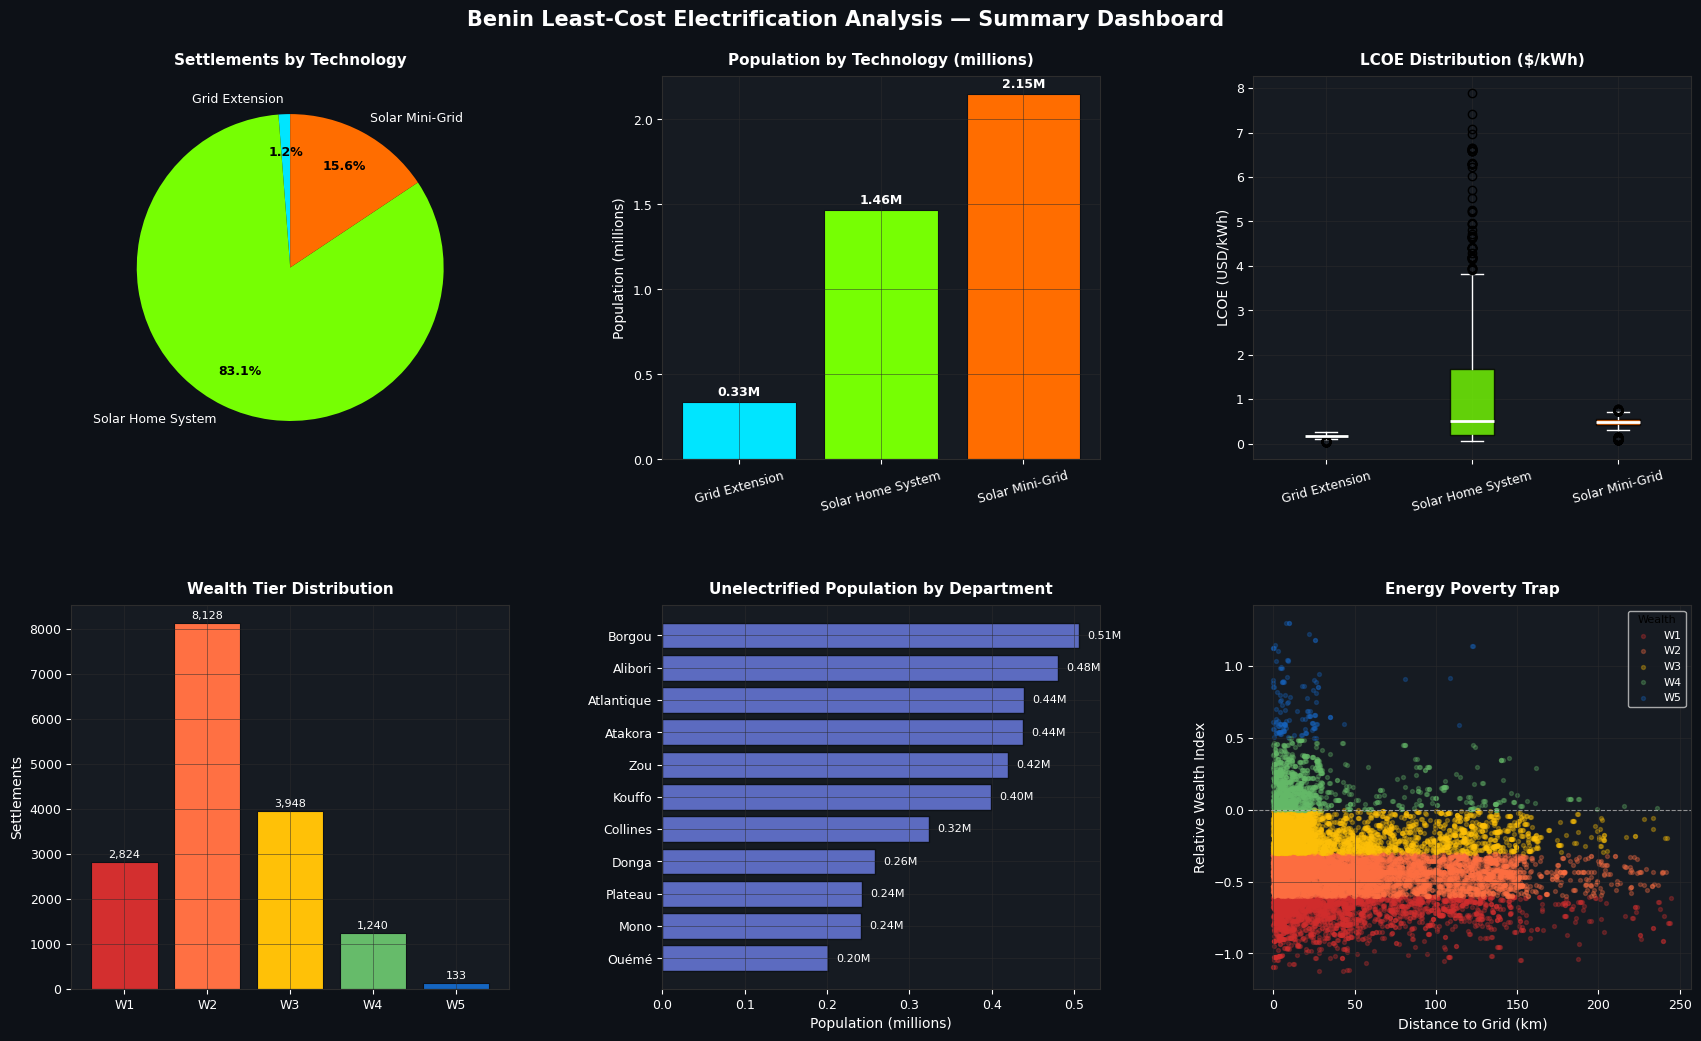

Chart 1 saved: outputs/figures/Chart1_Summary_Dashboard.png


In [55]:
# ═══════════════════════════════════════════════════════
# Cell 23 — Chart 1: Summary Dashboard
# ═══════════════════════════════════════════════════════

#One figure with six panels — the complete analysis story in one image.
#This is your technical presentation hero chart.

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.38, wspace=0.35,
                        left=0.07, right=0.97,
                        top=0.91, bottom=0.08)

COLORS  = ['#00E5FF', '#76FF03', '#FF6D00']
TECH    = ['Grid_Extension', 'SHS', 'Mini_Grid']
TLABELS = ['Grid Extension', 'Solar Home System', 'Solar Mini-Grid']
TEXT_COLOR = 'white'
GRID_COLOR = '#2D2D2D'

def style_ax(ax, title):
    ax.set_facecolor('#161B22')
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)
    ax.grid(color=GRID_COLOR, linewidth=0.5, alpha=0.7)

# ── PANEL 1: Settlements by technology (pie) ──────────
ax1 = fig.add_subplot(gs[0, 0])
tech_counts = [
    len(unelectrified[unelectrified['final_tech']==t]) for t in TECH
]
wedges, texts, autotexts = ax1.pie(
    tech_counts, labels=TLABELS, colors=COLORS,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75,
    textprops={'color': TEXT_COLOR, 'fontsize': 9}
)
for at in autotexts:
    at.set_color('black')
    at.set_fontweight('bold')
ax1.set_facecolor('#161B22')
ax1.set_title('Settlements by Technology',
              fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=8)

# ── PANEL 2: Population by technology (bar) ───────────
ax2 = fig.add_subplot(gs[0, 1])
pop_by_tech = [
    unelectrified[unelectrified['final_tech']==t]['population'].sum()/1e6
    for t in TECH
]
bars = ax2.bar(TLABELS, pop_by_tech, color=COLORS,
               edgecolor='#0D1117', linewidth=0.8)
for bar, val in zip(bars, pop_by_tech):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.2f}M', ha='center', va='bottom',
             color=TEXT_COLOR, fontsize=9, fontweight='bold')
style_ax(ax2, 'Population by Technology (millions)')
ax2.set_ylabel('Population (millions)', color=TEXT_COLOR)
ax2.tick_params(axis='x', rotation=15)

# ── PANEL 3: LCOE by technology (box) ─────────────────
ax3 = fig.add_subplot(gs[0, 2])
lcoe_data = [
    unelectrified[unelectrified['final_tech']==t]['winning_lcoe'].dropna()
    for t in TECH
]
bp = ax3.boxplot(lcoe_data, labels=TLABELS, patch_artist=True,
                  medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for element in ['whiskers','caps','fliers']:
    for item in bp[element]:
        item.set_color(TEXT_COLOR)
style_ax(ax3, 'LCOE Distribution ($/kWh)')
ax3.set_ylabel('LCOE (USD/kWh)', color=TEXT_COLOR)
ax3.tick_params(axis='x', rotation=15)

# ── PANEL 4: Wealth tier distribution (bar) ───────────
ax4 = fig.add_subplot(gs[1, 0])
tiers  = ['W1','W2','W3','W4','W5']
wcount = [len(unelectrified[unelectrified['wealth_tier']==t]) for t in tiers]
wcols  = [WEALTH_COLORS[t] for t in tiers]
bars4  = ax4.bar(tiers, wcount, color=wcols,
                  edgecolor='#0D1117', linewidth=0.8)
for bar, val in zip(bars4, wcount):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom',
             color=TEXT_COLOR, fontsize=8)
style_ax(ax4, 'Wealth Tier Distribution')
ax4.set_ylabel('Settlements', color=TEXT_COLOR)

# ── PANEL 5: Department breakdown (horizontal bar) ────
ax5 = fig.add_subplot(gs[1, 1])
dept_pop = unelectrified.groupby('admin_cgaz_1')['population']           .sum().sort_values(ascending=True) / 1e6
dept_pop = dept_pop[dept_pop.index.isin([
    'Alibori','Borgou','Atakora','Donga','Collines',
    'Zou','Kouffo','Mono','Plateau','Atlantique','Ouémé'
])]
bars5 = ax5.barh(dept_pop.index, dept_pop.values,
                  color='#5C6BC0', edgecolor='#0D1117')
for bar, val in zip(bars5, dept_pop.values):
    ax5.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}M', va='center',
             color=TEXT_COLOR, fontsize=8)
style_ax(ax5, 'Unelectrified Population by Department')
ax5.set_xlabel('Population (millions)', color=TEXT_COLOR)

# ── PANEL 6: Energy poverty trap ──────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for tier, color in WEALTH_COLORS.items():
    sub = unelectrified[unelectrified['wealth_tier']==tier]
    ax6.scatter(
        sub['distance_to_existing_transmission_lines'],
        sub['mean_rwi'],
        c=color, alpha=0.3, s=8, label=tier
    )
style_ax(ax6, 'Energy Poverty Trap')
ax6.set_xlabel('Distance to Grid (km)', color=TEXT_COLOR)
ax6.set_ylabel('Relative Wealth Index', color=TEXT_COLOR)
ax6.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax6.legend(fontsize=8, facecolor='#161B22',
           labelcolor=TEXT_COLOR, title='Wealth',
           title_fontsize=8)

# Main title
fig.suptitle(
    'Benin Least-Cost Electrification Analysis — Summary Dashboard',
    fontsize=15, fontweight='bold', color=TEXT_COLOR, y=0.97
)

plt.savefig('../outputs/figures/Chart1_Summary_Dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("Chart 1 saved: outputs/figures/Chart1_Summary_Dashboard.png")


In [ ]:
# ═══════════════════════════════════════════════════════
# Cell 24 — Chart 2: Technology by Department
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

BENIN_DEPTS = [
    'Alibori','Borgou','Atakora','Donga','Collines',
    'Zou','Kouffo','Mono','Plateau','Atlantique','Ouémé'
]

# ── LEFT: stacked bar — settlements by tech per dept ──
tech_dept = pd.crosstab(
    unelectrified['admin_cgaz_1'],
    unelectrified['final_tech']
).reindex(BENIN_DEPTS).fillna(0)

tech_dept_pct = tech_dept.div(tech_dept.sum(axis=1), axis=0) * 100

ax = axes[0]
ax.set_facecolor('#161B22')
bottom = np.zeros(len(tech_dept_pct))
for tech, color, label in zip(
    ['Grid_Extension','Mini_Grid','SHS'],
    ['#00E5FF','#FF6D00','#76FF03'],
    ['Grid Extension','Mini-Grid','SHS']
):
    if tech in tech_dept_pct.columns:
        vals = tech_dept_pct[tech].values
        ax.barh(tech_dept_pct.index, vals,
                left=bottom, color=color,
                label=label, edgecolor='#0D1117', linewidth=0.5)
        bottom += vals

ax.set_xlabel('Percentage of settlements (%)', color='white')
ax.set_title('Technology Mix by Department (%)',
             color='white', fontweight='bold', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#161B22', labelcolor='white', fontsize=9)
ax.set_xlim(0, 100)
for spine in ax.spines.values():
    spine.set_edgecolor('#2D2D2D')
ax.grid(axis='x', color='#2D2D2D', linewidth=0.5)

# ── RIGHT: population bar by dept ─────────────────────
ax2 = axes[1]
ax2.set_facecolor('#161B22')
dept_pop2 = unelectrified.groupby('admin_cgaz_1')['population']            .sum().reindex(BENIN_DEPTS).fillna(0) / 1000

bars = ax2.barh(dept_pop2.index, dept_pop2.values,
                color='#7B68EE', edgecolor='#0D1117')
for bar, val in zip(bars, dept_pop2.values):
    ax2.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}k', va='center', color='white', fontsize=9)
ax2.set_xlabel("Unelectrified population ('000s)", color='white')
ax2.set_title('Unelectrified Population by Department',
              color='white', fontweight='bold', fontsize=12)
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#2D2D2D')
ax2.grid(axis='x', color='#2D2D2D', linewidth=0.5)

fig.suptitle('Department-Level Analysis',
             color='white', fontweight='bold', fontsize=14)
plt.savefig('../outputs/figures/Chart2_Department_Breakdown.png',
            dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Chart 2 saved: outputs/figures/Chart2_Department_Breakdown.png")


In [ ]:
# ═══════════════════════════════════════════════════════
# Cell 25 — Chart 3: Energy Poverty Trap
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

# ── LEFT: RWI vs distance scatter ─────────────────────
ax1 = axes[0]
ax1.set_facecolor('#161B22')

for tier, color in WEALTH_COLORS.items():
    sub = unelectrified[unelectrified['wealth_tier']==tier]
    ax1.scatter(
        sub['distance_to_existing_transmission_lines'],
        sub['mean_rwi'],
        c=color, alpha=0.25, s=10, label=tier, zorder=2
    )

# Trend line
from numpy.polynomial.polynomial import polyfit
x = unelectrified['distance_to_existing_transmission_lines'].fillna(0)
y = unelectrified['mean_rwi'].fillna(-0.3)
coeffs = polyfit(x, y, 1)
x_line = np.linspace(0, x.max(), 100)
ax1.plot(x_line, coeffs[1]*x_line + coeffs[0],
         color='white', linewidth=1.5, linestyle='--',
         alpha=0.8, label='Trend', zorder=3)

ax1.axhline(0, color='#FFD700', linewidth=0.8,
            linestyle=':', alpha=0.7, label='Global avg wealth')
ax1.set_xlabel('Distance to Grid (km)', color='white')
ax1.set_ylabel('Relative Wealth Index', color='white')
ax1.set_title('Energy Poverty Trap\nPoorest settlements furthest from grid',
              color='white', fontweight='bold', fontsize=11)
ax1.tick_params(colors='white')
ax1.legend(facecolor='#161B22', labelcolor='white', fontsize=8)
for spine in ax1.spines.values():
    spine.set_edgecolor('#2D2D2D')
ax1.grid(color='#2D2D2D', linewidth=0.5, alpha=0.7)

# ── RIGHT: avg distance by wealth tier bar ────────────
ax2 = axes[1]
ax2.set_facecolor('#161B22')
tiers  = ['W1','W2','W3','W4','W5']
labels = ['Very Poor\n(W1)','Poor\n(W2)','Average\n(W3)',
          'Above Avg\n(W4)','Wealthy\n(W5)']
dists  = [
    unelectrified[unelectrified['wealth_tier']==t]
    ['distance_to_existing_transmission_lines'].mean()
    for t in tiers
]
wcols  = [WEALTH_COLORS[t] for t in tiers]
bars   = ax2.bar(labels, dists, color=wcols,
                  edgecolor='#0D1117', linewidth=0.8)
for bar, val in zip(bars, dists):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}km', ha='center', va='bottom',
             color='white', fontsize=10, fontweight='bold')
ax2.set_ylabel('Avg distance to grid (km)', color='white')
ax2.set_title('Average Distance to Grid by Wealth Tier\n'
              'The poorest are furthest from electricity',
              color='white', fontweight='bold', fontsize=11)
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#2D2D2D')
ax2.grid(axis='y', color='#2D2D2D', linewidth=0.5, alpha=0.7)

fig.suptitle('The Energy Poverty Trap — Benin',
             color='white', fontweight='bold', fontsize=14)
plt.savefig('../outputs/figures/Chart3_Energy_Poverty_Trap.png',
            dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Chart 3 saved — this is your most powerful analytical finding")


In [ ]:
# ═══════════════════════════════════════════════════════
#  Cell 26 — Chart 4: Satellite Insights From GEE
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0D1117')

# ── PANEL 1: Solar GHI north vs south ────────────────
ax1 = axes[0,0]
ax1.set_facecolor('#161B22')

north_depts = ['Alibori','Borgou','Atakora','Donga']
south_depts = ['Atlantique','Ouémé','Mono','Kouffo']
mid_depts   = ['Collines','Zou','Plateau']

solar_by_dept = unelectrified.groupby('admin_cgaz_1')['solar_ghi_kwh'].mean()
solar_by_dept = solar_by_dept.reindex([
    'Alibori','Atakora','Borgou','Donga','Collines',
    'Zou','Plateau','Kouffo','Mono','Atlantique','Ouémé'
]).dropna()

bar_colors = []
for dept in solar_by_dept.index:
    if dept in north_depts: bar_colors.append('#FF6B35')
    elif dept in south_depts: bar_colors.append('#4FC3F7')
    else: bar_colors.append('#81C784')

bars = ax1.bar(solar_by_dept.index, solar_by_dept.values,
               color=bar_colors, edgecolor='#0D1117')
ax1.axhline(5.49, color='white', linewidth=1,
            linestyle='--', label=f'National avg: 5.49')
ax1.set_ylabel('Solar GHI (kWh/m²/day)', color='white')
ax1.set_title('Solar Resource by Department\n(GEE NASA ERA5)',
              color='white', fontweight='bold')
ax1.tick_params(colors='white', axis='x', rotation=45)
ax1.tick_params(colors='white', axis='y')
ax1.legend(facecolor='#161B22', labelcolor='white', fontsize=9)
for spine in ax1.spines.values(): spine.set_edgecolor('#2D2D2D')
ax1.grid(axis='y', color='#2D2D2D', alpha=0.7)

# ── PANEL 2: Land use distribution — fixed ────────────────
ax2 = axes[0,1]
ax2.set_facecolor('#161B22')

lu_counts = unelectrified['landuse_label'].value_counts()

# Only show categories with > 1% — merge tiny ones into 'Other'
threshold = len(unelectrified) * 0.01
lu_main   = lu_counts[lu_counts >= threshold]
lu_other  = lu_counts[lu_counts < threshold].sum()
if lu_other > 0:
    lu_main['Other'] = lu_other

lu_colors_map = {
    'Cropland':       '#81C784',
    'Forest':         '#2E7D32',
    'Shrubland':      '#A5D6A7',
    'Grassland':      '#C5E1A5',
    'Built-up':       '#EF9A9A',
    'Bare vegetation':'#BCAAA4',
    'Water body':     '#4FC3F7',
    'Wetland':        '#80DEEA',
    'Unknown':        '#757575',
    'Other':          '#455A64'
}
colors_list = [lu_colors_map.get(l, '#888') for l in lu_main.index]

# Explode small slices away from centre to prevent overlap
explode = [0.05 if v/lu_main.sum() < 0.08 else 0
           for v in lu_main.values]

wedges, texts, autotexts = ax2.pie(
    lu_main.values,
    labels=None,              # no inline labels — use legend instead
    colors=colors_list,
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    startangle=90,
    pctdistance=0.75,
    explode=explode,
    textprops={'color': 'white', 'fontsize': 8}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(8)

# Clean legend outside the pie — no overlap possible
ax2.legend(
    wedges,
    [f"{l} ({v/lu_main.sum()*100:.0f}%)"
     for l, v in zip(lu_main.index, lu_main.values)],
    loc='center left',
    bbox_to_anchor=(0.95, 0.5),
    fontsize=7,
    facecolor='#161B22',
    labelcolor='white',
    framealpha=0.8
)
ax2.set_facecolor('#161B22')
ax2.set_title('Land Use Distribution\n(ESA WorldCover 2021 via GEE)',
              color='white', fontweight='bold', fontsize=10)

# ── PANEL 3: NDVI by land use ─────────────────────────
ax3 = axes[1,0]
ax3.set_facecolor('#161B22')
ndvi_by_lu = unelectrified.groupby('landuse_label')['ndvi']             .mean().sort_values(ascending=True)
bars3 = ax3.barh(ndvi_by_lu.index, ndvi_by_lu.values,
                  color='#66BB6A', edgecolor='#0D1117')
ax3.axvline(0.3, color='#FFD700', linewidth=1,
            linestyle='--', label='Productive threshold (0.3)')
for bar, val in zip(bars3, ndvi_by_lu.values):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', color='white', fontsize=9)
ax3.set_xlabel('Mean NDVI', color='white')
ax3.set_title('Agricultural Productivity by Land Use\n(Sentinel-2 NDVI via GEE)',
              color='white', fontweight='bold')
ax3.tick_params(colors='white')
ax3.legend(facecolor='#161B22', labelcolor='white', fontsize=9)
for spine in ax3.spines.values(): spine.set_edgecolor('#2D2D2D')
ax3.grid(axis='x', color='#2D2D2D', alpha=0.7)

# ── PANEL 4: Rainfall by department ───────────────────
ax4 = axes[1,1]
ax4.set_facecolor('#161B22')
rain_dept = unelectrified.groupby('admin_cgaz_1')['rainfall_mm']            .mean().sort_values(ascending=False)
rain_dept = rain_dept.head(11)
rain_colors = ['#1565C0' if v > 1200 else
               '#42A5F5' if v > 900 else '#EF9A9A'
               for v in rain_dept.values]
bars4 = ax4.bar(rain_dept.index, rain_dept.values,
                color=rain_colors, edgecolor='#0D1117')
ax4.axhline(1200, color='#1565C0', linewidth=1,
            linestyle='--', label='High rainfall (1200mm)')
ax4.axhline(900, color='#EF9A9A', linewidth=1,
            linestyle='--', label='Low rainfall (900mm)')
ax4.set_ylabel('Annual rainfall (mm)', color='white')
ax4.set_title('Annual Rainfall by Department\n(CHIRPS 2023 via GEE)',
              color='white', fontweight='bold')
ax4.tick_params(colors='white', axis='x', rotation=45)
ax4.tick_params(colors='white', axis='y')
ax4.legend(facecolor='#161B22', labelcolor='white', fontsize=8)
for spine in ax4.spines.values(): spine.set_edgecolor('#2D2D2D')
ax4.grid(axis='y', color='#2D2D2D', alpha=0.7)

fig.suptitle('Satellite Intelligence — Google Earth Engine Insights',
             color='white', fontweight='bold', fontsize=14)
plt.savefig('../outputs/figures/Chart4_Satellite_Insights.png',
            dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Chart 4 saved: outputs/figures/Chart4_Satellite_Insights.png")


In [59]:
# ═══════════════════════════════════════════════════════
# Cell 27 — All Outputs Summary
# ═══════════════════════════════════════════════════════

import os

print("=" * 55)
print("ALL OUTPUTS GENERATED")
print("=" * 55)

print("\nINTERACTIVE MAPS (open in browser):")
maps_dir = '../outputs/maps/'
for f in sorted(os.listdir(maps_dir)):
    if f.endswith('.html'):
        size = os.path.getsize(maps_dir + f) / 1024
        print(f"  {f} ({size:.0f}KB)")

print("\nCHARTS (for presentation slides):")
figs_dir = '../outputs/figures/'
for f in sorted(os.listdir(figs_dir)):
    if f.endswith('.png'):
        size = os.path.getsize(figs_dir + f) / 1024
        print(f"  {f} ({size:.0f}KB)")

print("\nDATA FILES:")
proc_dir = '../data/processed/'
if os.path.exists(proc_dir):
    for f in sorted(os.listdir(proc_dir)):
        size = os.path.getsize(proc_dir + f) / 1024
        print(f"  {f} ({size:.0f}KB)")

print("\nHOW TO USE EACH OUTPUT:")
print("  Maps  → open .html in Chrome/Edge → screenshot for slides")
print("          OR share the link via GitHub Pages")
print("  Charts → drag .png directly into PowerPoint slides")
print("  CSV   → submit with GitHub repository")

print("\nREADY FOR PRESENTATIONS AND GITHUB PUSH")


ALL OUTPUTS GENERATED

INTERACTIVE MAPS (open in browser):
  Map1_Technology_Assignment.html (26047KB)
  Map2_Solar_Resource.html (16611KB)
  Map3_Wealth_Affordability.html (20241KB)
  Map4_Priority_Settlements.html (7719KB)
  Map5_VIIRS_Nightlights.html (8584KB)

CHARTS (for presentation slides):
  Chart1_Summary_Dashboard.png (399KB)
  Chart2_Department_Breakdown.png (90KB)
  Chart3_Energy_Poverty_Trap.png (280KB)
  Chart4_Satellite_Insights.png (242KB)

DATA FILES:
  Benin_Unelectrified_Final.csv (533KB)
  benin_results.csv (5603KB)

HOW TO USE EACH OUTPUT:
  Maps  → open .html in Chrome/Edge → screenshot for slides
          OR share the link via GitHub Pages
  Charts → drag .png directly into PowerPoint slides
  CSV   → submit with GitHub repository

READY FOR PRESENTATIONS AND GITHUB PUSH
